# Exploratory Data Analysis (EDA) : 

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('New_Dataset/cleaned_data_1.csv')
df.head()

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,...,Qty,Unit_Price,ship-city,ship-state,ship-postal-code,B2B,Month_Name,Day_name,Quarter_Year,Total_Revenue
0,405-8078784-5731545,2022-04-30,Cancelled,merchant,amazon.in,standard,SET389,SET389-KR-NP-S,set,S,...,0,647.62,Mumbai,Maharashtra,400081.0,False,April,Saturday,2022-Q1,0.0
1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,merchant,amazon.in,standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,...,1,406.00,Bengaluru,Karnataka,560085.0,False,April,Saturday,2022-Q1,406.0
2,404-0687676-7273146,2022-04-30,Shipped,amazon,amazon.in,expedited,JNE3371,JNE3371-KR-XL,kurta,XL,...,1,329.00,Navi Mumbai,Maharashtra,410210.0,True,April,Saturday,2022-Q1,329.0
3,403-9615377-8133951,2022-04-30,Cancelled,merchant,amazon.in,standard,J0341,J0341-DR-L,western,L,...,0,753.33,Puducherry,Puducherry,605008.0,False,April,Saturday,2022-Q1,0.0
4,407-1069790-7240320,2022-04-30,Shipped,amazon,amazon.in,expedited,JNE3671,JNE3671-TU-XXXL,top,3XL,...,1,574.00,Chennai,Tamil Nadu,600073.0,False,April,Saturday,2022-Q1,574.0


# Sales Improvement Analysis

# Revenue Trend : 

## Daily Total Revenue Trend

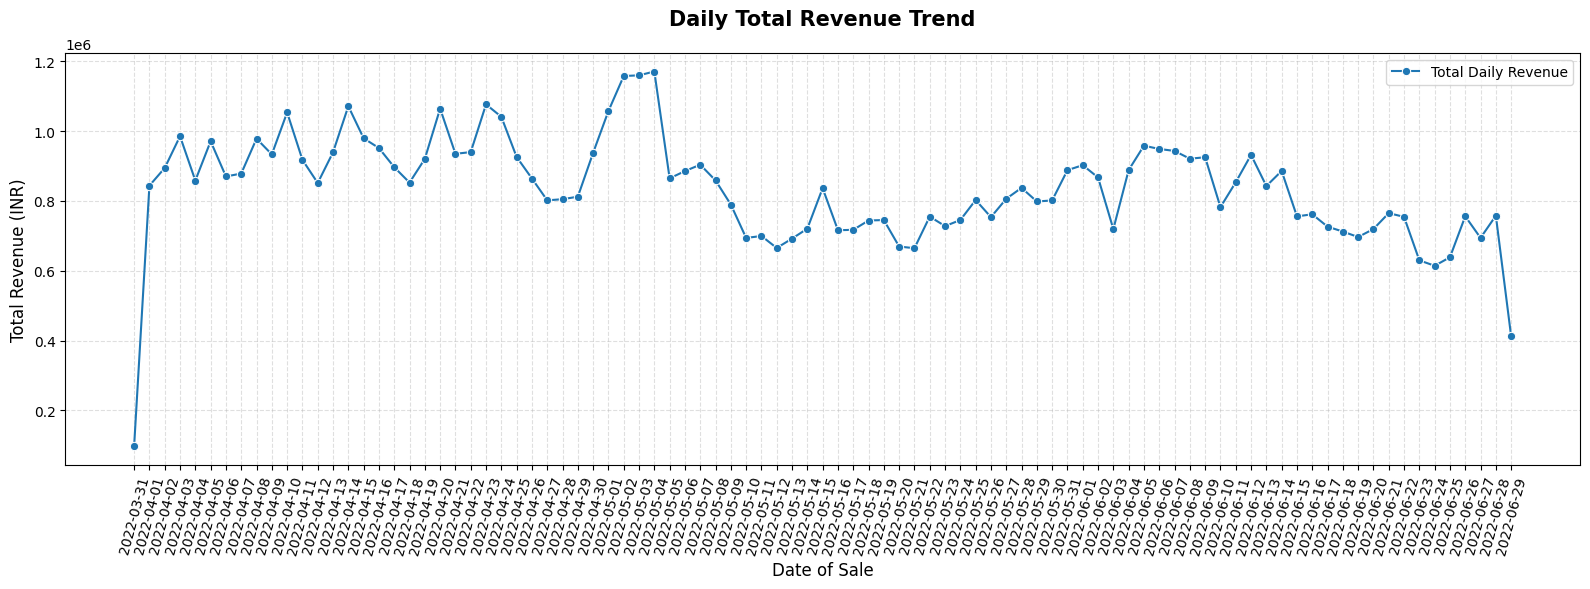

In [3]:
#Used Seaborn for the visualization 
trend_df=df.groupby('Date')['Total_Revenue'].sum().sort_index().reset_index()

plt.figure(figsize=(16,6))
sns.lineplot(data=trend_df, x='Date', y='Total_Revenue',marker='o',label='Total Daily Revenue')

plt.title('Daily Total Revenue Trend', fontsize=15,fontweight='bold', pad=20)
plt.xlabel('Date of Sale', fontsize=12)
plt.ylabel('Total Revenue (INR)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

### Insights  : <br>
The daily fluctuations suggest we have specific 'power days' that drive outsized revenue

## Monthly Total Revenue Trend

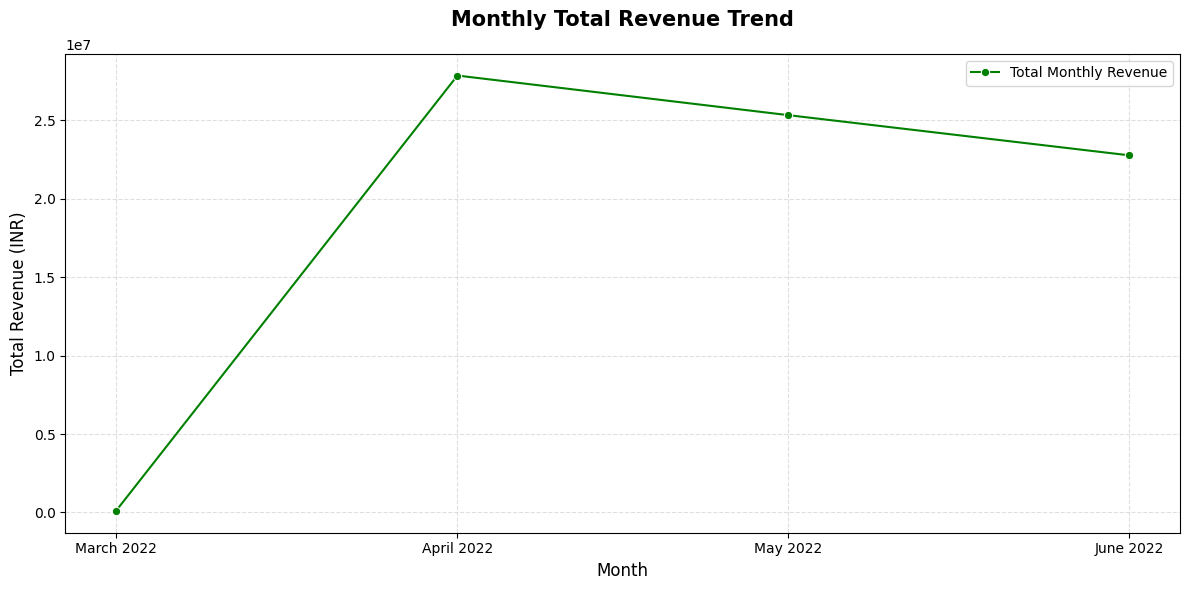

In [4]:
df['Date'] = pd.to_datetime(df['Date'])
monthly_trend_df = df.groupby(df['Date'].dt.to_period('M'))['Total_Revenue'].sum().reset_index()

monthly_trend_df['Date'] = monthly_trend_df['Date'].dt.to_timestamp()

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_trend_df, x='Date', y='Total_Revenue', marker='o', color='green', label='Total Monthly Revenue')

plt.title('Monthly Total Revenue Trend', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue (INR)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)

plt.xticks(monthly_trend_df['Date'], monthly_trend_df['Date'].dt.strftime('%B %Y'))

plt.tight_layout()
plt.show()

### Insights : <br>
Monthly trend shows a stable trajectory in revenue contribution.

## KPI 1 : Total Revenue and Total Orders

In [34]:
total_revenue = df['Total_Revenue'].sum()
total_orders = df['Order ID'].nunique()

print(f"Total Revenue: {total_revenue}")
print(f"Total Orders: {total_orders}")

Total Revenue: 76034406.0
Total Orders: 120378


# Category Trend :

## Quantity sold by category :

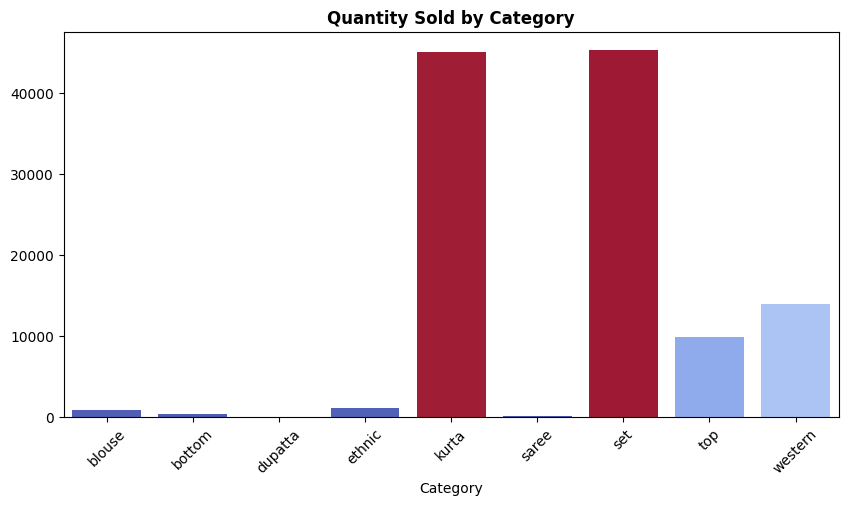

In [5]:
category_df=df.groupby('Category')['Qty'].sum()

plt.figure(figsize=(10,5))
sns.barplot(x=category_df.index, y=category_df.values, palette='coolwarm', hue=category_df, legend=False)

plt.title("Quantity Sold by Category", fontweight='bold', fontsize='12')
plt.xticks(rotation=45)
plt.show()

### Insight : <br>
Kurta and Sets are the highest selling categories

## Revenue per Category

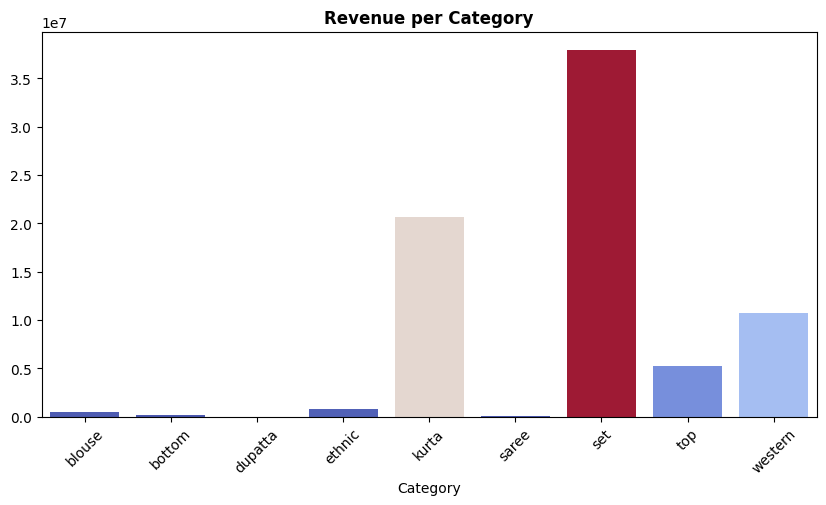

In [6]:
category_df=df.groupby('Category')['Total_Revenue'].sum()

plt.figure(figsize=(10,5))
sns.barplot(x=category_df.index, y=category_df.values, palette='coolwarm', hue=category_df, legend=False)

plt.title("Revenue per Category", fontweight='bold', fontsize='12')
plt.xticks(rotation=45)
plt.show()

### Insights : 
While kurta and sets were the top selling categories, Set has the highest revenue generation , while kurta comes in mid position(which says that individual cost of kurta are relatively cheaper), then western clothes come in.

# City Trend : 

## Pie Chart of Cities by Total Quantity Ordered

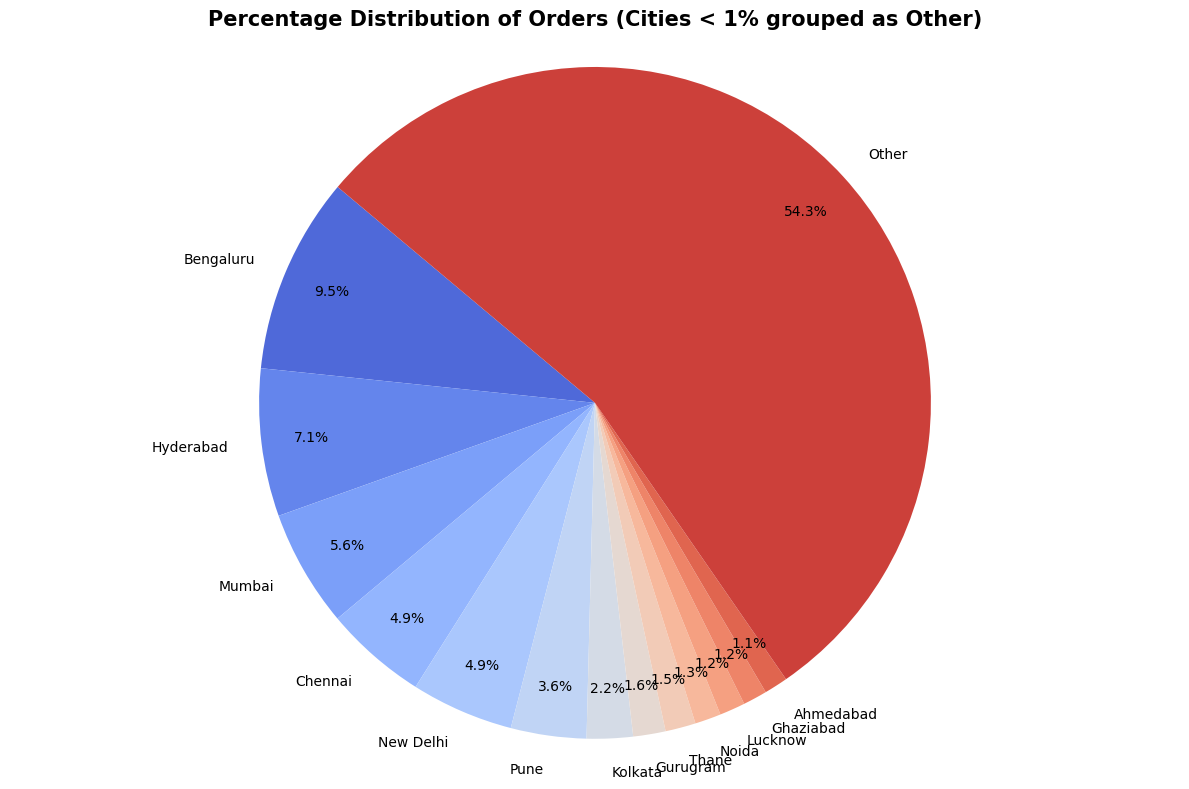

In [7]:
city_qty_all = df.groupby('ship-city')['Qty'].sum().sort_values(ascending=False)
total_qty = city_qty_all.sum()
city_percentages = 100 * (city_qty_all / total_qty)

high_impact_cities = city_qty_all[city_percentages >= 1.1].copy()
other_cities_qty = city_qty_all[city_percentages < 1.1].sum()

stco_final = high_impact_cities
stco_final['Other'] = other_cities_qty

plt.figure(figsize=(12, 8))
colors = sns.color_palette('coolwarm', len(stco_final))

plt.pie(
    stco_final, 
    labels=stco_final.index, 
    autopct='%1.1f%%',   
    startangle=140,      
    colors=colors,
    pctdistance=0.85,
    labeldistance=1.1
)

plt.title('Percentage Distribution of Orders (Cities < 1% grouped as Other)', fontsize=15, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

In [8]:
total_qty_overall = df['Qty'].sum()

city_qty_all = df.groupby('ship-city')['Qty'].sum().sort_values(ascending=False)
top_10_cities = city_qty_all.head(10)

total_qty_top_10 = top_10_cities.sum()
percentage_contribution = (total_qty_top_10 / total_qty_overall) * 100

print(f"Total Quantity Sold (Overall): {total_qty_overall}")
print(f"Total Quantity Sold by Top 10 Cities: {total_qty_top_10}")
print(f"Percentage Contribution of Top 10 Cities: {percentage_contribution:.1f}%")
print("\n--- Breakdown by City ---")
print(top_10_cities)

Total Quantity Sold (Overall): 116649
Total Quantity Sold by Top 10 Cities: 49216
Percentage Contribution of Top 10 Cities: 42.2%

--- Breakdown by City ---
ship-city
Bengaluru    11038
Hyderabad     8284
Mumbai        6576
Chennai       5756
New Delhi     5754
Pune          4237
Kolkata       2586
Gurugram      1815
Thane         1703
Noida         1467
Name: Qty, dtype: int64


## Top 10 Cities by Total Quantity Ordered

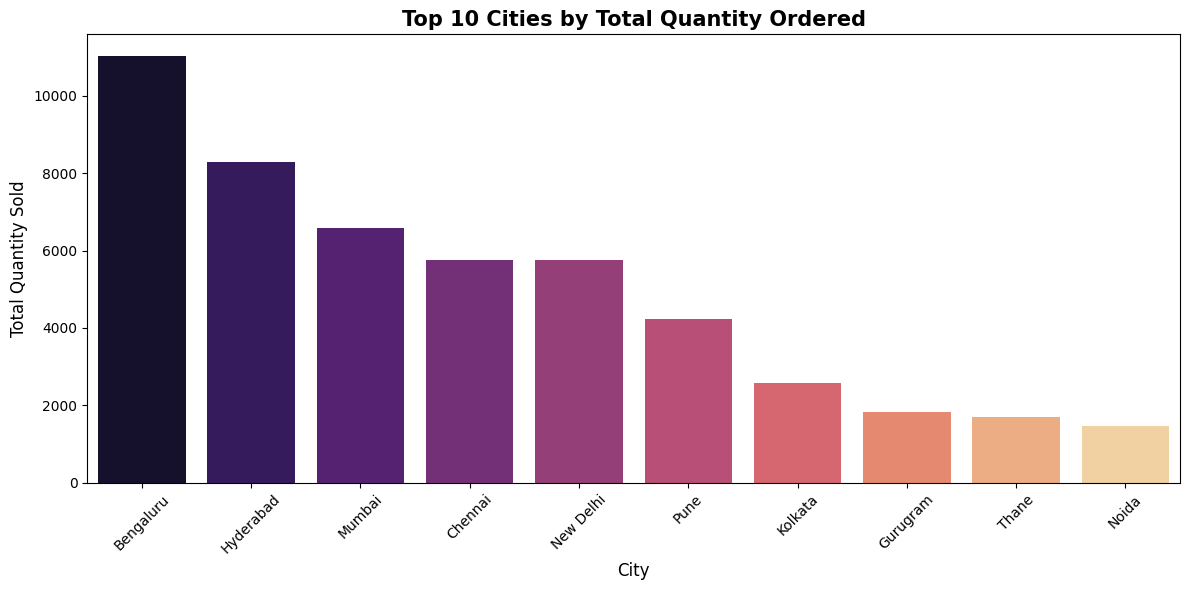

In [9]:
city_qty = df.groupby('ship-city')['Qty'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=city_qty, x='ship-city', y='Qty', palette='magma', hue='ship-city', legend=False)
plt.title('Top 10 Cities by Total Quantity Ordered', fontsize=15, fontweight='bold')
plt.xlabel('City', fontsize=12)
plt.ylabel('Total Quantity Sold', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Percentage Distribution of Orders by Top 10 Cities

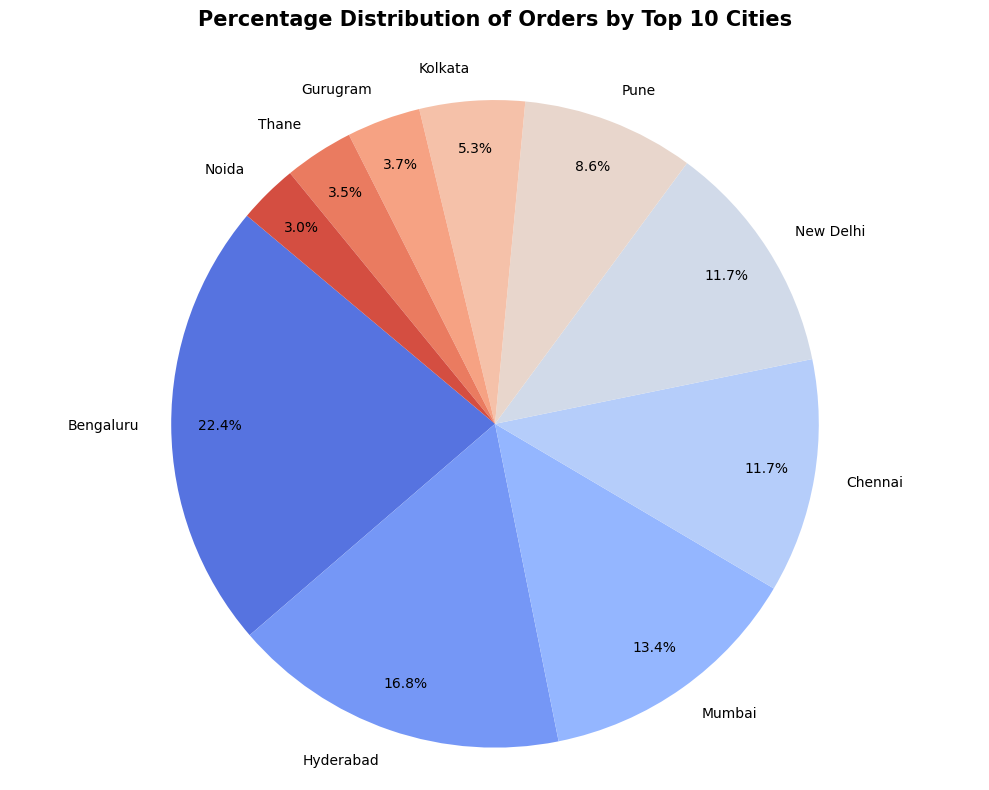

In [10]:
city_qty = df.groupby('ship-city')['Qty'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 8))
colors = sns.color_palette('coolwarm', len(city_qty))

plt.pie(
    city_qty, 
    labels=city_qty.index, 
    autopct='%1.1f%%',   
    startangle=140,      
    colors=colors,
    pctdistance=0.85,    
)

plt.title('Percentage Distribution of Orders by Top 10 Cities', fontsize=15, fontweight='bold',pad=30)
plt.axis('equal')
plt.tight_layout()
plt.show()

## KPI 2 - Most Profitable City : 

In [11]:
profitable_city = df.groupby('ship-city')['Total_Revenue'].sum().idxmax()
city_revenue = df.groupby('ship-city')['Total_Revenue'].sum().max()

print(f"Most Profitable City: {profitable_city} with Revenue: {city_revenue}")

Most Profitable City: Bengaluru with Revenue: 7104012.0


### Insight : 
Top 10 cities contribute around 42.2 % of revenue and among them Bengaluru has the highest revenue (7.1 M) contributing 9.5% among all cities and 22.4% among the top 10 cities.

## Category Demand Breakdown in Top 6 Cities

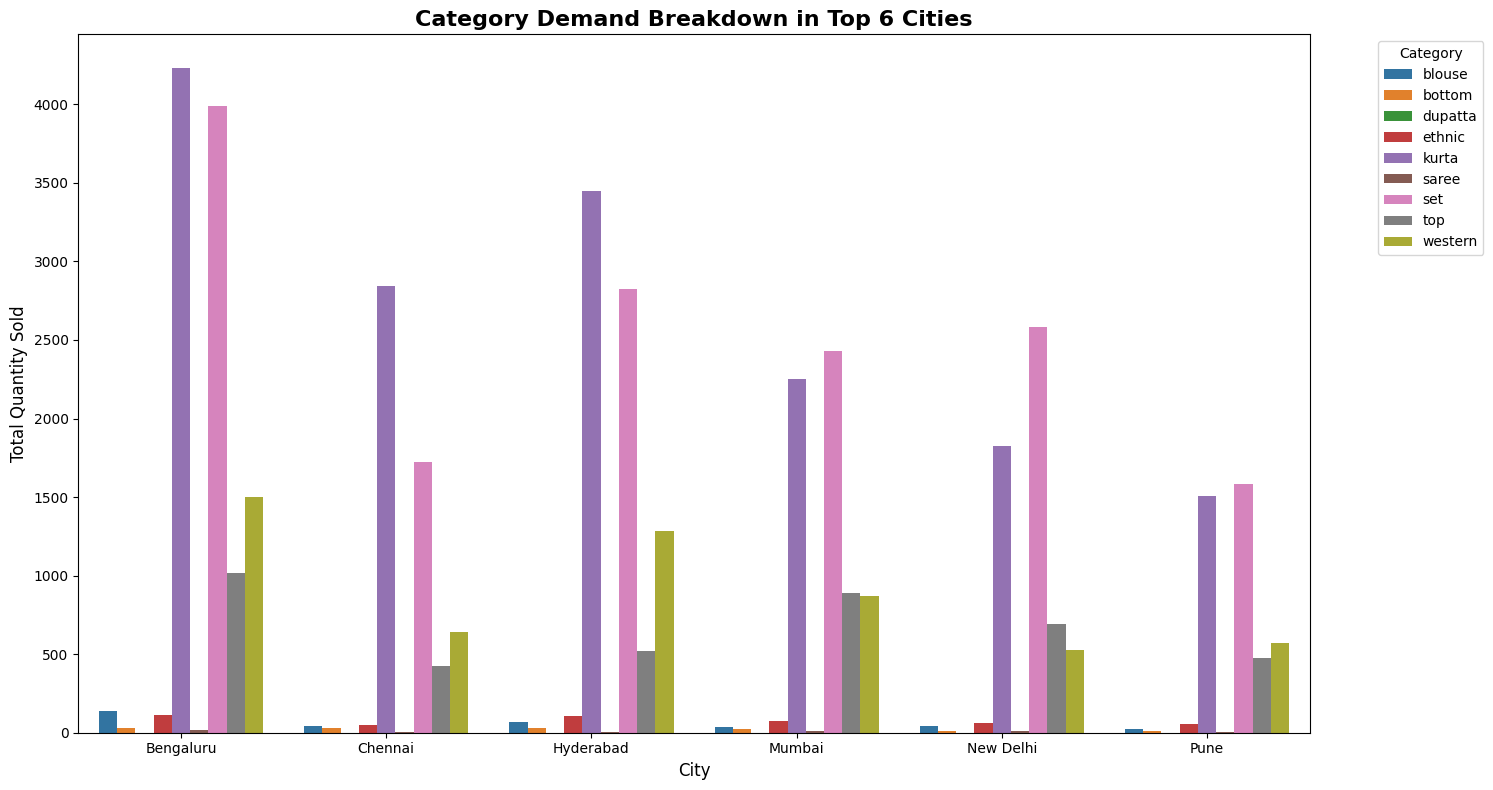

In [12]:
top_cities = ['Bengaluru', 'Hyderabad', 'New Delhi', 'Mumbai', 'Chennai', 'Pune']

top_cities_df = df[df['ship-city'].isin(top_cities)]

city_category_analysis = top_cities_df.groupby(['ship-city', 'Category'])['Qty'].sum().reset_index()

plt.figure(figsize=(15, 8))
sns.barplot(data=city_category_analysis, x='ship-city', y='Qty', hue='Category')

plt.title('Category Demand Breakdown in Top 6 Cities', fontsize=16, fontweight='bold')
plt.xlabel('City', fontsize=12)
plt.ylabel('Total Quantity Sold', fontsize=12)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Insights : <br>
Took top 6 cities, which categories sell out the most among these cities.<br>
Bengaluru - Kurta, Set, Western<br>
Hyderabad - Kurta, Set, Western<br>
Mumbai - Set, Kurta, Western<br>
Delhi - Set, Kurta, Western<br>



In the Major cities, as the demand is super high : <br>
Instead of Single Warehouse system present in some particular place(Delhi NCR), we can bring up "Dark Stores" warehousing to the major cities (Bengaluru, Hyderabad), which will help us increase the speed of delivery of the products<br>
Quick Commerce or One Day delivery option can be brought in Major Cities so that sales are high.


Ads system : 
Instead of common ads throughout the nation, we can customize the ads based on the city trends, <br>
Bengaluru - Promote more about the Kurtas, focus on the western clothes.<br>
Mumbai and Delhi - Promote more about the Sets.

## KPI 3 - Category Revenue Contribution

In [35]:
category_revenue = df.groupby('Category')['Total_Revenue'].sum().sort_values(ascending=False)
category_perc = (category_revenue / total_revenue) * 100

print("Category Contribution to Total Revenue:")
print(category_perc)

Category Contribution to Total Revenue:
Category
set        49.891143
kurta      27.192096
western    14.083009
top         6.895472
ethnic      1.003426
blouse      0.580341
bottom      0.187902
saree       0.165408
dupatta     0.001203
Name: Total_Revenue, dtype: float64


# Business Model Trend : 

## Order Volume: B2C vs. B2B

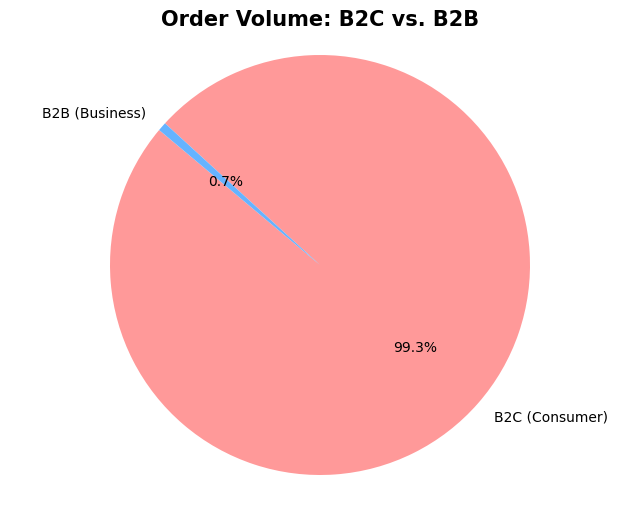

In [13]:
b2b_counts = df['B2B'].value_counts()
plt.figure(figsize=(8, 6))
plt.pie(b2b_counts, labels=['B2C (Consumer)', 'B2B (Business)'], autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff'])
plt.title('Order Volume: B2C vs. B2B', fontsize=15, fontweight='bold')
plt.axis('equal')
plt.show()

## Total Revenue Contribution: B2B vs. B2B

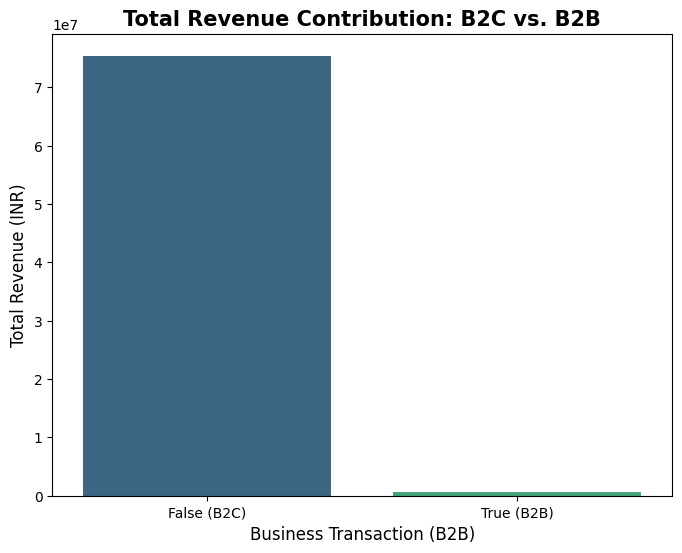

In [14]:
b2b_revenue = df.groupby('B2B')['Total_Revenue'].sum().reset_index()
plt.figure(figsize=(8, 6))
sns.barplot(data=b2b_revenue, x='B2B', y='Total_Revenue', palette='viridis', hue='B2B', legend=False)
plt.title('Total Revenue Contribution: B2C vs. B2B', fontsize=15, fontweight='bold')
plt.xlabel('Business Transaction (B2B)', fontsize=12)
plt.ylabel('Total Revenue (INR)', fontsize=12)
plt.xticks([0, 1], ['False (B2C)', 'True (B2B)'])
plt.show()

In [15]:
df['B2B'].value_counts()

B2B
False    128104
True        871
Name: count, dtype: int64

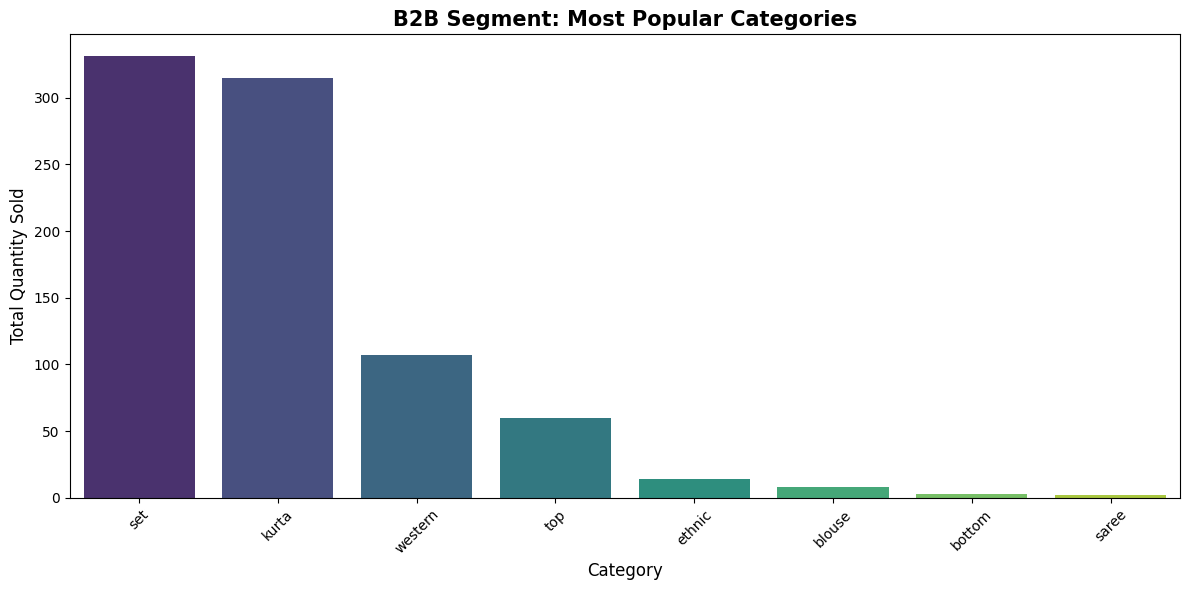

In [22]:
b2b_df = df[df['B2B'] == True]
b2b_category_qty = b2b_df.groupby('Category')['Qty'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=b2b_category_qty, x='Category', y='Qty', palette='viridis', hue='Category', legend=False)
plt.title('B2B Segment: Most Popular Categories', fontsize=15, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Quantity Sold', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

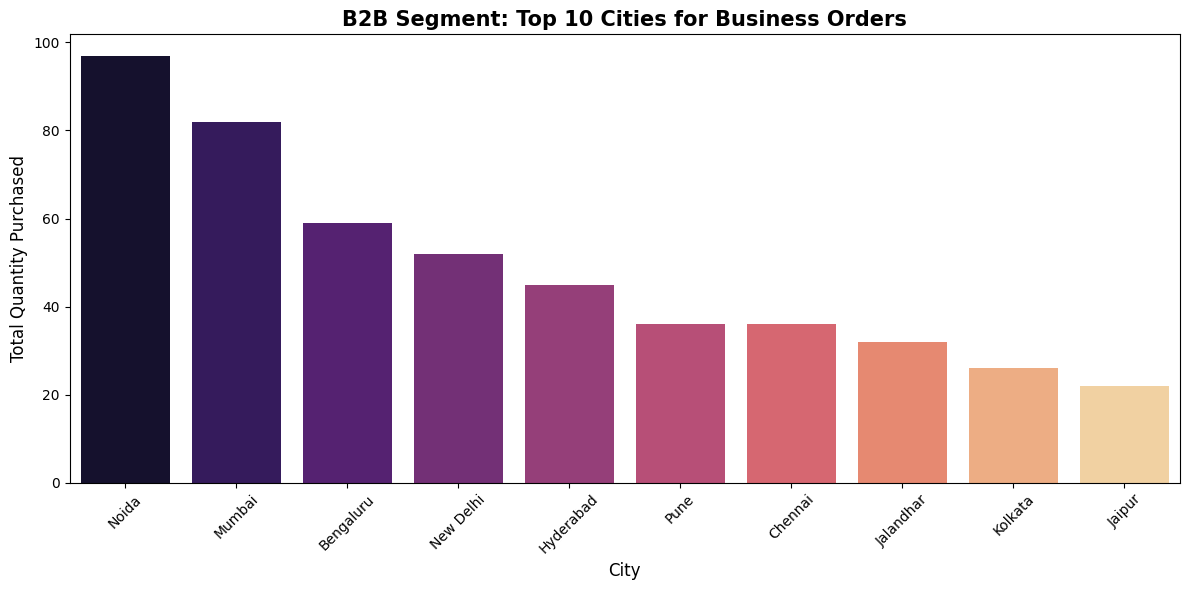

In [24]:
b2b_city_qty = b2b_df.groupby('ship-city')['Qty'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=b2b_city_qty, x='ship-city', y='Qty', palette='magma', hue='ship-city', legend=False)
plt.title('B2B Segment: Top 10 Cities for Business Orders', fontsize=15, fontweight='bold')
plt.xlabel('City', fontsize=12)
plt.ylabel('Total Quantity Purchased', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

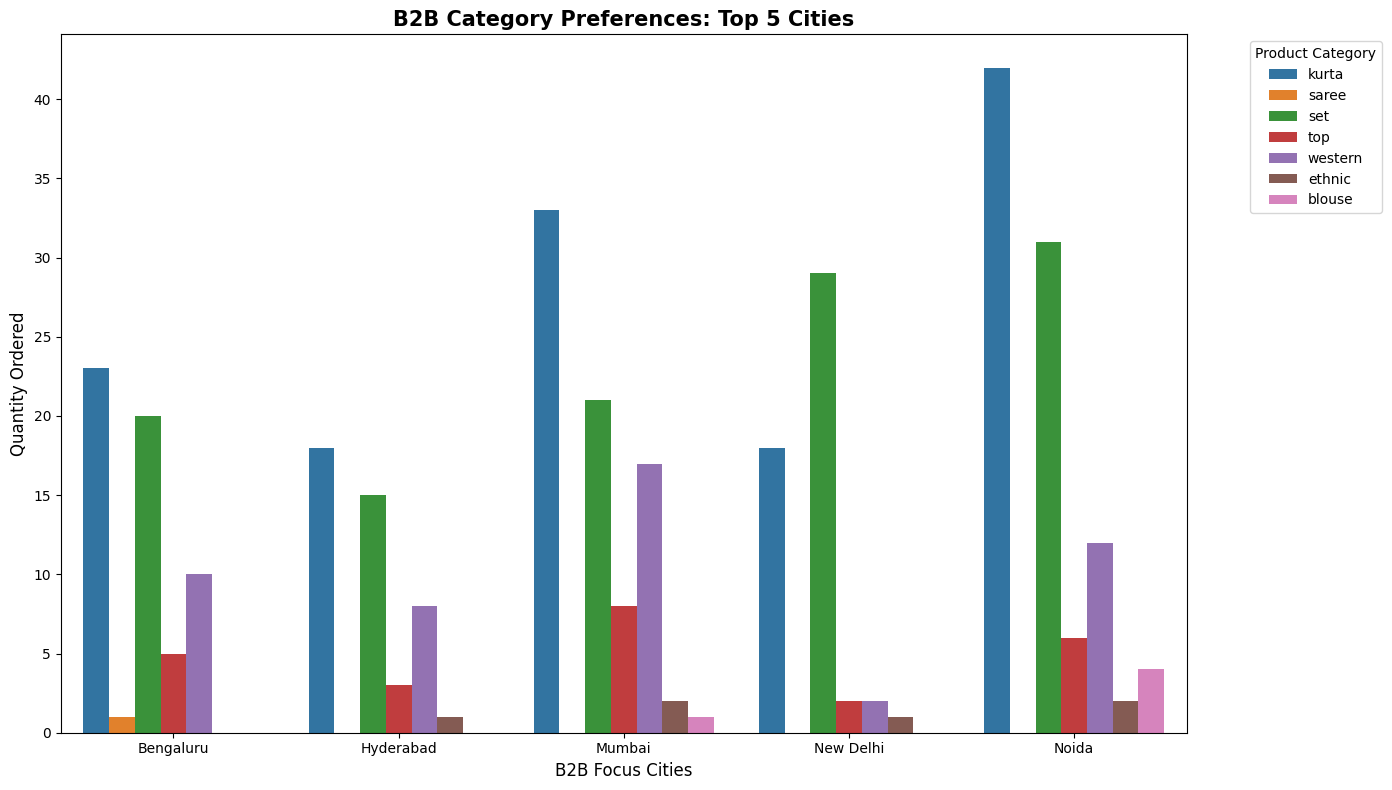

In [27]:
top_b2b_cities = ['Noida', 'Mumbai', 'Bengaluru', 'New Delhi','Hyderabad']

b2b_city_data = df[(df['B2B'] == True) & (df['ship-city'].isin(top_b2b_cities))]

b2b_category_breakdown = b2b_city_data.groupby(['ship-city', 'Category'])['Qty'].sum().reset_index()

plt.figure(figsize=(14, 8))
sns.barplot(data=b2b_category_breakdown, x='ship-city', y='Qty', hue='Category')

plt.title('B2B Category Preferences: Top 5 Cities', fontsize=15, fontweight='bold')
plt.xlabel('B2B Focus Cities', fontsize=12)
plt.ylabel('Quantity Ordered', fontsize=12)
plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [29]:
df['ship-city'] = df['ship-city'].str.title()
top_b2b_cities = ['Noida', 'Mumbai', 'Bengaluru', 'New Delhi', 'Hyderabad']
b2b_city_data = df[(df['B2B'] == True) & (df['ship-city'].isin(top_b2b_cities))]

b2b_value_table = b2b_city_data.pivot_table(
    index='ship-city', 
    columns='Category', 
    values='Qty', 
    aggfunc='sum', 
    fill_value=0
).loc[top_b2b_cities] 

print("--- B2B Category Quantity Breakdown per Top City ---")
print(b2b_value_table)

b2b_revenue_table = b2b_city_data.groupby('ship-city')['Total_Revenue'].sum().sort_values(ascending=False)
print("\n--- B2B Total Revenue per City ---")
print(b2b_revenue_table)

--- B2B Category Quantity Breakdown per Top City ---
Category   blouse  ethnic  kurta  saree  set  top  western
ship-city                                                 
Noida           4       2     42      0   31    6       12
Mumbai          1       2     33      0   21    8       17
Bengaluru       0       0     23      1   20    5       10
New Delhi       0       1     18      0   29    2        2
Hyderabad       0       1     18      0   15    3        8

--- B2B Total Revenue per City ---
ship-city
Noida        63306.0
Mumbai       55772.0
Bengaluru    43770.0
New Delhi    42335.0
Hyderabad    33707.0
Name: Total_Revenue, dtype: float64


## KPI 3:  Average Order Value(AOV) : 

In [30]:
aov_results = df.groupby('B2B')['Total_Revenue'].mean()

print(f"B2C Average Order Value (False): {aov_results[False]:.2f}")
print(f"B2B Average Order Value (True): {aov_results[True]:.2f}")

B2C Average Order Value (False): 588.72
B2B Average Order Value (True): 708.59


In [31]:
df_b2b = df[df['B2B'] == True]

b2b_city_aov = df_b2b.groupby('ship-city')['Total_Revenue'].mean().sort_values(ascending=False)

print("--- B2B Average Order Value (AOV) per City ---")
print(b2b_city_aov.head(10))

--- B2B Average Order Value (AOV) per City ---
ship-city
Nagapattinam          3344.000000
Jalandhar             2004.038462
Giridih               1473.000000
Ankleshwar            1168.000000
Guwahati              1126.000000
Port Blair            1125.000000
Mumbai-400051         1106.500000
Bengalurubangalore    1072.000000
Ambala                1002.666667
Allahabad              999.000000
Name: Total_Revenue, dtype: float64


In [32]:
b2b_category_aov = df_b2b.groupby('Category')['Total_Revenue'].mean().sort_values(ascending=False)

print("\n--- B2B Average Order Value (AOV) per Category ---")
print(b2b_category_aov)


--- B2B Average Order Value (AOV) per Category ---
Category
set        949.591176
saree      825.500000
ethnic     788.400000
western    735.929204
top        534.295082
kurta      489.750000
blouse     392.875000
bottom     327.250000
Name: Total_Revenue, dtype: float64


In [33]:
top_b2b_cities = ['Noida', 'Mumbai', 'Bengaluru', 'New Delhi', 'Hyderabad']

df_top_b2b = df_b2b[df_b2b['ship-city'].isin(top_b2b_cities)]

b2b_city_cat_aov = df_top_b2b.pivot_table(
    index='ship-city', 
    columns='Category', 
    values='Total_Revenue', 
    aggfunc='mean'
).fillna(0)

print("\n--- B2B AOV: Category-wise in Top 5 Cities ---")
print(b2b_city_cat_aov)


--- B2B AOV: Category-wise in Top 5 Cities ---
Category   blouse  ethnic       kurta  saree          set         top  \
ship-city                                                               
Bengaluru    0.00     0.0  519.608696  832.0  1039.050000  486.200000   
Hyderabad    0.00   837.0  645.875000    0.0  1081.857143  457.000000   
Mumbai     383.00   958.0  588.151515    0.0   688.454545  538.375000   
New Delhi    0.00   899.0  476.277778    0.0  1038.379310  599.500000   
Noida      411.25   865.0  449.108696    0.0   866.903226  643.333333   

Category      western  
ship-city              
Bengaluru  777.500000  
Hyderabad  752.375000  
Mumbai     913.187500  
New Delhi  775.500000  
Noida      656.769231  


#### B2B Advantage
##### Observation: B2B AOV (₹708) is 20% higher than B2C (₹588).
##### Insight: Every business order is significantly more valuable than a consumer order.
<br>

#### "Sets" are the Profit King
##### Observation: The "Set" category has the highest AOV at ₹949.59, nearly double that of Kurtas (₹489).
##### Insight: "Sets" are your most efficient revenue generator. In cities like Hyderabad and Bengaluru, business customers are paying a premium (over ₹1,000) for Sets.
<br>

#### City-Specific "Hero" Products
##### Each city shows a unique strength where you can maximize profit:
##### Mumbai is the "Western" Hub: It has the highest AOV for Western wear (₹913). Mumbai business partners are buying your most expensive Western designs.
##### Hyderabad is the "Set" Hub: It leads in AOV for Sets (₹1,081). This is your "gold mine" city-category combination.
##### New Delhi is the "Premium Ethnic" Hub: While it has lower volume, its AOV for Sets (₹1,038) and Ethnic wear (₹899) is very high.
<br>

#### Geographic "Whale" Cities
##### Observation: Cities like Nagapattinam (₹3,344) and Jalandhar (₹2,004) have massive AOVs.
##### Insight: While these may be lower volume, they represent "Whale" clients (large boutiques or retailers).

# Descriptive Statistics : 

In [18]:
df.drop(columns=['Date','ship-postal-code']).describe()

,Qty,Unit_Price,Total_Revenue
count,128975.000000,128975.000000,128975.000000
mean,0.904431,609.363662,589.528250
std,0.313354,313.347147,386.784628
min,0.000000,0.000000,0.000000
25%,1.000000,413.000000,399.000000
50%,1.000000,583.000000,568.000000
75%,1.000000,771.000000,771.000000
max,15.000000,5584.000000,44672.000000


### Insight :
#### Qty : 50% and 75% are both 1, which shows majority of products purchased are 1 in quantity. "Frequently Bought Together" can be used to improve Qty from 1 to 2
#### Revenue : Mean(589) and Median-50%(568) are very close, which says that the pricing is very stable, people are ok spending along 400 to 800.
#### Outliers : Max Qty(15) and Max Revenue(44672) tells the average order is small, there are rare "whale" orders. These are almost certainly B2B transactions.

# Correlations Matrix : 

In [19]:
correlation_mat=df.drop(columns=['ship-postal-code']).corr(numeric_only=True)

In [20]:
correlation_mat

,Qty,Unit_Price,B2B,Total_Revenue
Qty,1.000000,0.391096,0.015783,0.579881
Unit_Price,0.391096,1.000000,0.018268,0.842030
B2B,0.015783,0.018268,1.000000,0.025382
Total_Revenue,0.579881,0.842030,0.025382,1.000000


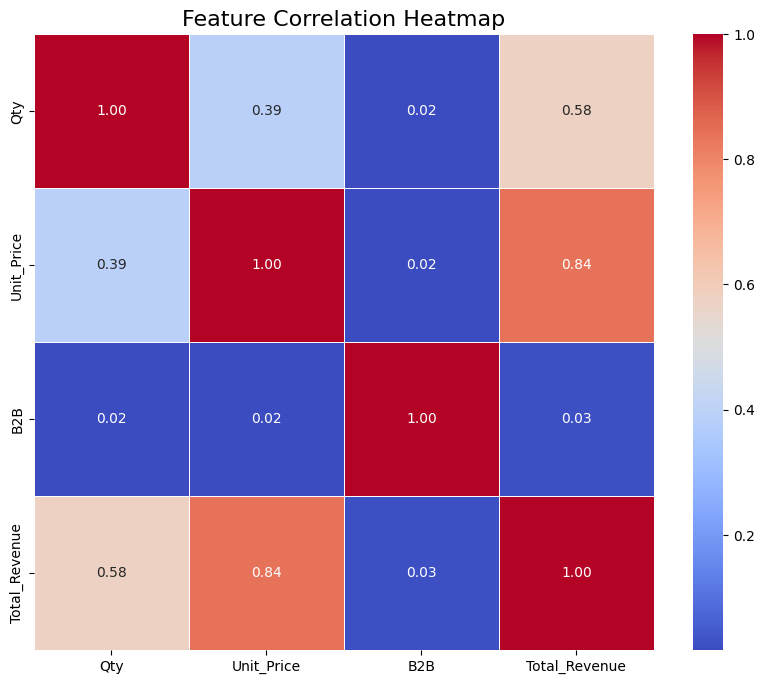

In [21]:
plt.figure(figsize=(10,8))

sns.heatmap(correlation_mat,annot=True,cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.show()